In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from insilico_stimuli.stimuli import CenterSurround

In [2]:
results_fname = Path("/src/project/hierarchical_3_grating_analysis.csv")
results = pd.read_csv(results_fname)

In [3]:
results

,Unnamed: 0,gratings_offset,x_sigma,i_sigma,mei_means,mei_mean_mean_chains,mei_mean_sde_chains,completing_means,completing_mean_mean_chains,completing_mean_sde_chains,...,disrupting_mean_sde_chains_2,completing_gain,completing_gain_mean_chains,completing_gain_sde_chains,disrupting_gain_1,disrupting_gain_mean_chains_1,disrupting_gain_sde_chains_1,disrupting_gain_2,disrupting_gain_mean_chains_2,disrupting_gain_sde_chains_2
0,0,0.947368,0.1,1.0,[0.91156262 0.91179952 0.915775 0.91962465 0...,0.915192,0.001396,[0.91445137 0.90932 0.91758128 0.91574541 0...,0.914392,0.001232,...,0.001179,[ 0.003169 -0.00271937 0.0019724 -0.004218...,-0.000869,0.001294,[ 0.00269571 0.0044673 -0.00402961 -0.004808...,-0.000564,0.001629,[ 5.38945944e-03 1.67502561e-03 -2.85281848e-...,-0.000153,0.001603
1,1,0.315789,0.1,0.1,[0.99902197 0.99892231 0.9984013 0.99890601 0...,0.998719,0.000128,[1.00020168 1.00003518 0.99962166 0.99999032 0...,0.999891,0.000106,...,0.000053,[0.00118087 0.00111407 0.00122231 0.0010855 0...,0.001173,0.000030,[-0.0005909 -0.00018704 -0.00016164 -0.000319...,-0.000338,0.000071,[-6.39747798e-04 -5.48347389e-04 7.08838550e-...,-0.000243,0.000164
2,2,0.631579,1.0,0.1,[0.99994884 1.00046935 1.00013466 0.99972096 0...,0.999953,0.000150,[0.99981784 1.00063459 1.00013845 1.00009993 1...,1.000174,0.000118,...,0.000072,[-1.30998853e-04 1.65162376e-04 3.78539429e-...,0.000220,0.000129,[-0.00041947 -0.00030261 -0.00032305 -0.000138...,-0.000141,0.000145,[-1.34296088e-05 -2.51787881e-04 -1.91952954e-...,-0.000021,0.000090
3,3,0.052632,1.0,1.0,[0.98786525 0.98590083 0.98517031 0.98306692 0...,0.985410,0.000691,[0.99897443 1.00210036 0.99542159 0.9983521 0...,0.998778,0.000951,...,0.000654,[0.01124565 0.0164312 0.0104056 0.01554847 0...,0.013567,0.001057,[-0.00165485 -0.00035867 0.00324891 0.002183...,0.000503,0.000842,[-0.00217997 0.00267216 0.00080145 0.001633...,0.000457,0.000763
4,4,0.263158,0.1,0.1,[0.99865323 0.9987842 0.99839166 0.99829097 0...,0.998478,0.000092,[0.99985271 0.99970809 0.99966508 0.99948468 0...,0.999685,0.000053,...,0.000063,[0.0012011 0.00092501 0.00127547 0.00119576 0...,0.001209,0.000076,[ 7.52245746e-05 -8.64653800e-05 -1.03389787e-...,-0.000039,0.000033,[-8.77328516e-05 -3.88612622e-04 -1.27175023e-...,-0.000091,0.000087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,0.473684,0.1,0.1,[0.99899751 0.99866986 0.99893146 0.99874837 0...,0.998767,0.000082,[0.99966788 0.99940695 0.99960042 0.9993855 0...,0.999512,0.000049,...,0.000065,[0.00067105 0.00073808 0.00066967 0.00063793 0...,0.000746,0.000061,[-0.00056236 -0.0007145 -0.00075083 -0.000353...,-0.000514,0.000096,[-0.00088466 -0.00024511 -0.00088186 -0.000406...,-0.000555,0.000122
76,76,0.105263,1.0,0.1,[0.99984075 0.99996008 0.99995697 0.99982962 1...,0.999940,0.000046,[0.99959876 1.00018211 1.00016101 0.99986034 1...,0.999969,0.000097,...,0.000054,[-2.42030852e-04 2.22029772e-04 2.04051570e-...,0.000029,0.000078,[ 3.30825766e-04 -2.69668421e-04 1.55857506e-...,-0.000026,0.000109,[-3.43212150e-04 -3.61813638e-04 -1.84969510e-...,-0.000251,0.000056
77,77,0.000000,1.0,0.1,[0.99998549 0.9996793 0.99980227 1.00006518 0...,0.999842,0.000071,[0.99975123 1.00007635 0.99985425 0.99997725 1...,0.999941,0.000054,...,0.000014,[-2.34269116e-04 3.97174661e-04 5.19860334e-...,0.000099,0.000111,[-1.19027118e-05 -1.35692198e-04 -7.83278163e-...,-0.000046,0.000085,[-2.77671942e-04 9.22487806e-05 -7.83653555e-...,-0.000120,0.000083
78,78,0.631579,0.1,1.0,[0.89372783 0.89436805 0.9005333 0.90188055 0...,0.897411,0.001460,[0.97673432 0.97492639 0.97478923 0.97273406 0...,0.975401,0.000783,...,0.001655,[0.09287669 0.09007292 0.08245773 0.07856197 0...,0.086925,0.002443,[-0.06860287 -0.07090923 -0.07454252 -0.070520...,-0.070243,0.001178,[-0.06905715 -0.07281256 -0.07346543 -0.074610...,-0.070504,0.001959


In [4]:
results_part = results[(results["x_sigma"] == 0.1) & (results["i_sigma"] == 1.0)]

<Axes: xlabel='gratings_offset', ylabel='disrupting_mean_mean_chains_2'>

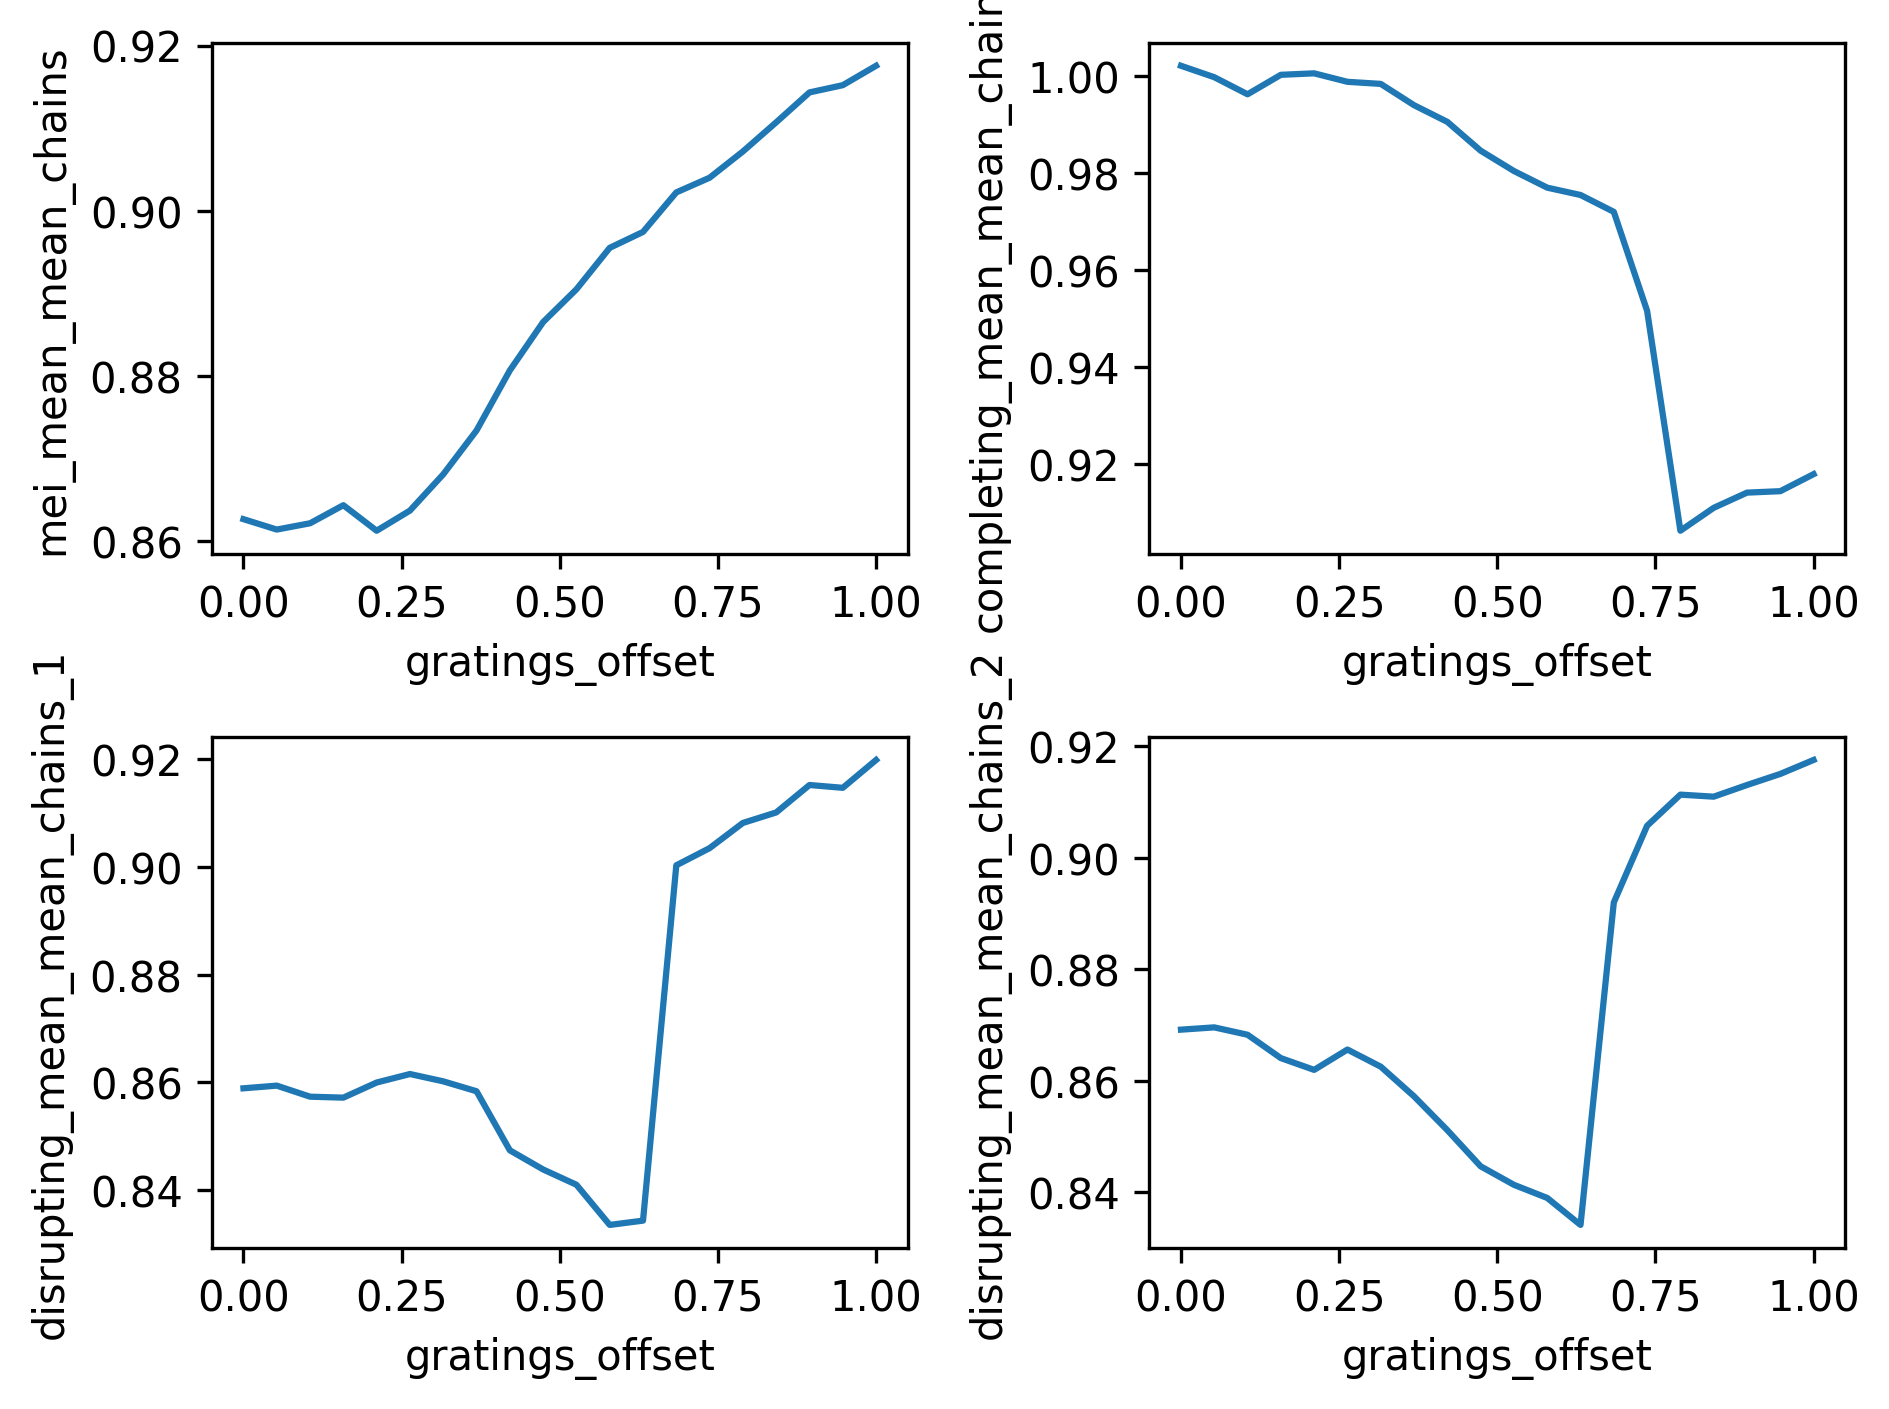

In [5]:
fig, axs = plt.subplots(nrows=2, ncols=2, dpi=300, tight_layout=True)
sns.lineplot(results_part, x="gratings_offset", y="mei_mean_mean_chains", ax=axs[0, 0])
# add error bars using ax.errorbar

sns.lineplot(
    results_part, x="gratings_offset", y="completing_mean_mean_chains", ax=axs[0, 1]
)
sns.lineplot(
    results_part, x="gratings_offset", y="disrupting_mean_mean_chains_1", ax=axs[1, 0]
)
sns.lineplot(
    results_part, x="gratings_offset", y="disrupting_mean_mean_chains_2", ax=axs[1, 1]
)

In [6]:
results_part.columns

Index(['Unnamed: 0', 'gratings_offset', 'x_sigma', 'i_sigma', 'mei_means',
       'mei_mean_mean_chains', 'mei_mean_sde_chains', 'completing_means',
       'completing_mean_mean_chains', 'completing_mean_sde_chains',
       'disrupting_means_1', 'disrupting_mean_mean_chains_1',
       'disrupting_mean_sde_chains_1', 'disrupting_means_2',
       'disrupting_mean_mean_chains_2', 'disrupting_mean_sde_chains_2',
       'completing_gain', 'completing_gain_mean_chains',
       'completing_gain_sde_chains', 'disrupting_gain_1',
       'disrupting_gain_mean_chains_1', 'disrupting_gain_sde_chains_1',
       'disrupting_gain_2', 'disrupting_gain_mean_chains_2',
       'disrupting_gain_sde_chains_2'],
      dtype='object')

[Text(0, -0.1, '-10%'),
 Text(0, -0.08, '-8%'),
 Text(0, -0.06, '-6%'),
 Text(0, -0.039999999999999994, '-4%'),
 Text(0, -0.01999999999999999, '-2%'),
 Text(0, 1.3877787807814457e-17, ' 0%'),
 Text(0, 0.020000000000000018, ' 2%'),
 Text(0, 0.04000000000000001, ' 4%'),
 Text(0, 0.060000000000000026, ' 6%'),
 Text(0, 0.08000000000000004, ' 8%'),
 Text(0, 0.10000000000000003, ' 10%'),
 Text(0, 0.12000000000000002, ' 12%'),
 Text(0, 0.14000000000000004, ' 14%'),
 Text(0, 0.16000000000000006, ' 16%'),
 Text(0, 0.18000000000000002, ' 18%'),
 Text(0, 0.20000000000000004, ' 20%')]

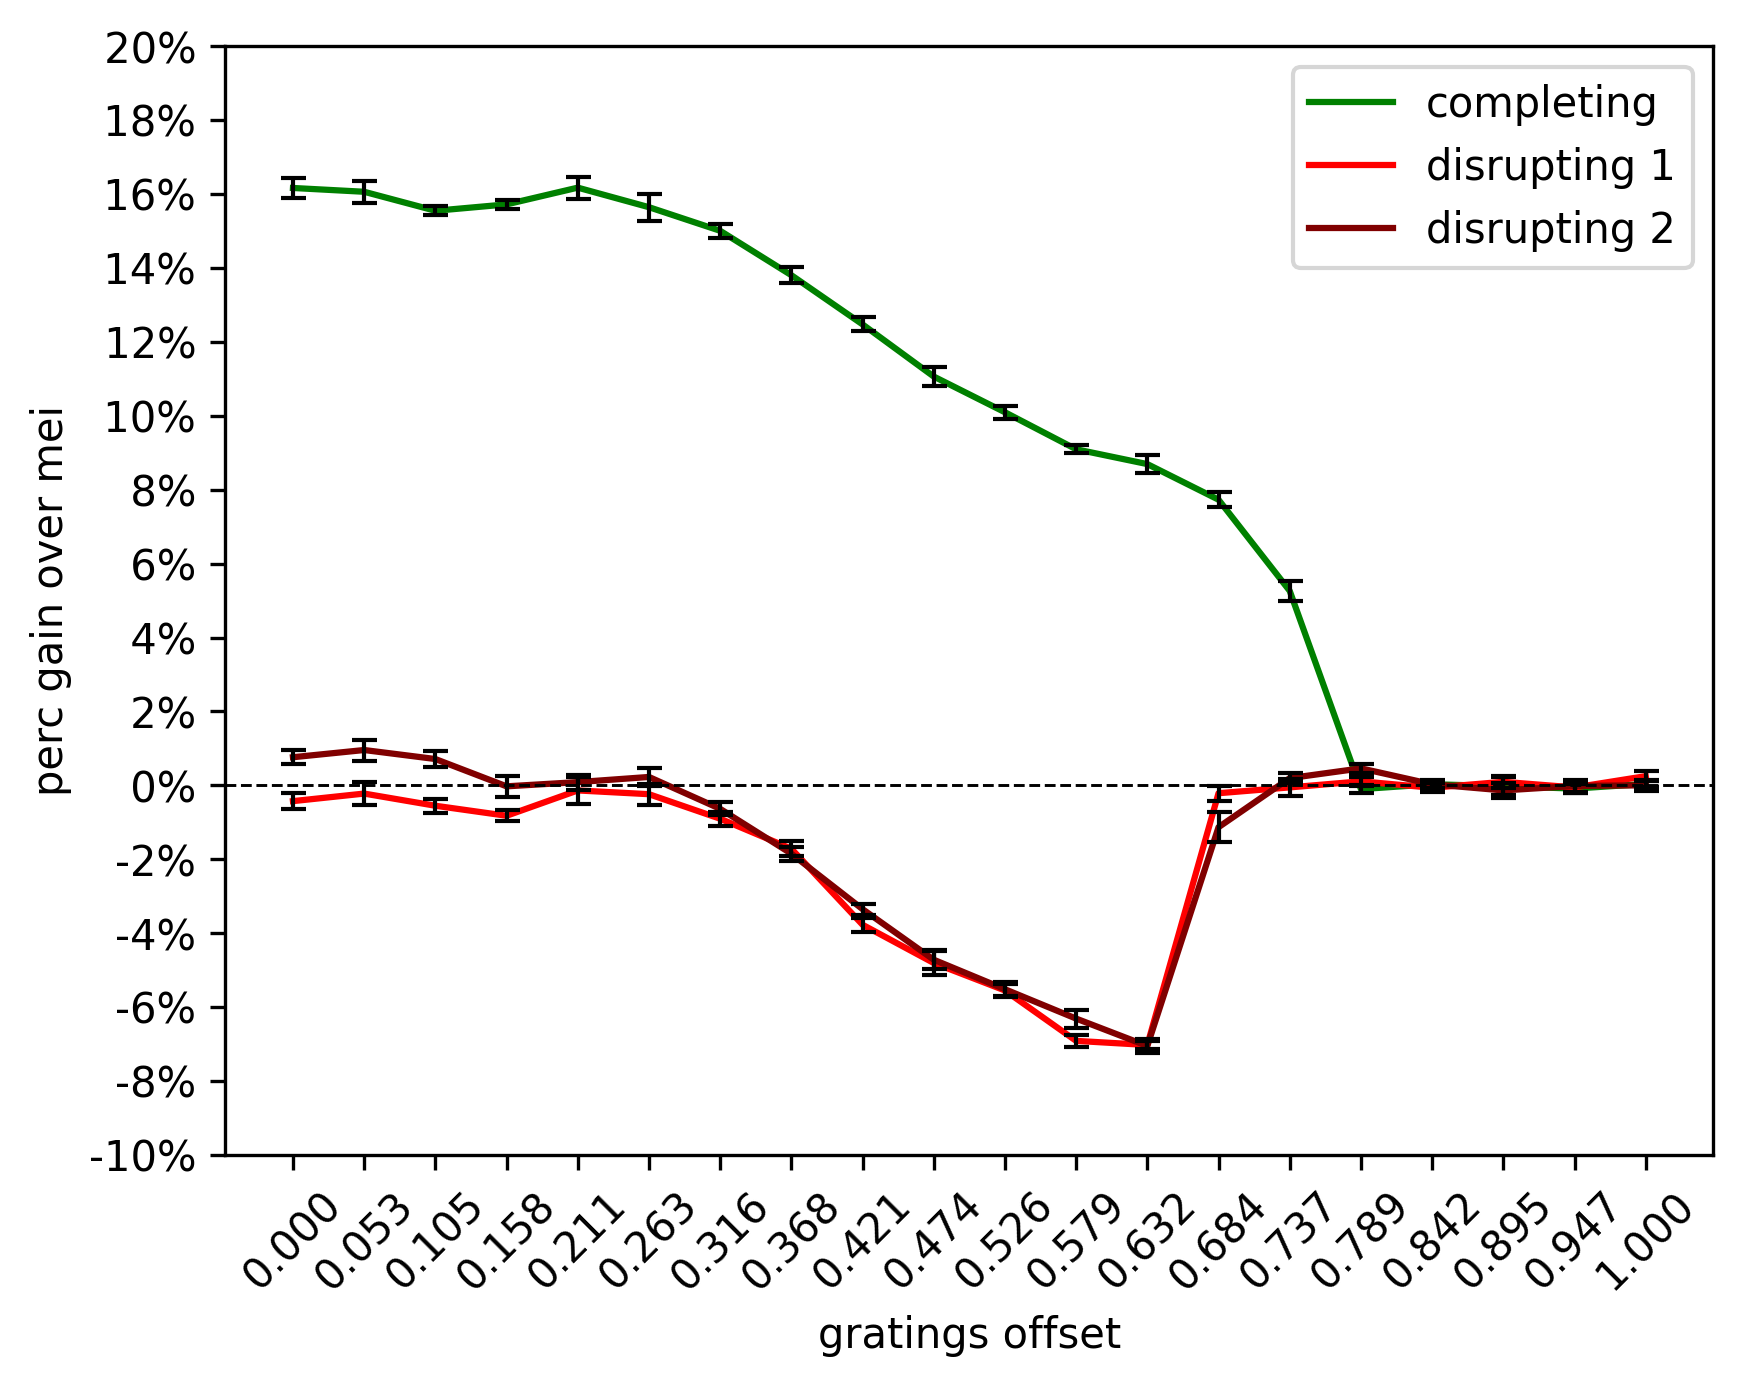

In [19]:
fig, ax = plt.subplots(dpi=300)
sns.lineplot(
    results_part,
    x="gratings_offset",
    y="completing_gain_mean_chains",
    color="green",
    ax=ax,
    label="completing",
)
sns.lineplot(
    results_part,
    x="gratings_offset",
    y="disrupting_gain_mean_chains_1",
    color="red",
    ax=ax,
    label="disrupting 1",
)
sns.lineplot(
    results_part,
    x="gratings_offset",
    y="disrupting_gain_mean_chains_2",
    color="maroon",
    ax=ax,
    label="disrupting 2",
)

for gratings_offset in sorted(results_part["gratings_offset"]):
    ax.errorbar(
        x=results_part[results_part["gratings_offset"] == gratings_offset][
            "gratings_offset"
        ],
        y=results_part[results_part["gratings_offset"] == gratings_offset][
            "completing_gain_mean_chains"
        ],
        yerr=results_part[results_part["gratings_offset"] == gratings_offset][
            "completing_gain_sde_chains"
        ],
        capsize=3,
        elinewidth=1,
        capthick=1,
        color="black",
    )
    ax.errorbar(
        x=results_part[results_part["gratings_offset"] == gratings_offset][
            "gratings_offset"
        ],
        y=results_part[results_part["gratings_offset"] == gratings_offset][
            "disrupting_gain_mean_chains_1"
        ],
        yerr=results_part[results_part["gratings_offset"] == gratings_offset][
            "disrupting_gain_sde_chains_1"
        ],
        capsize=3,
        elinewidth=1,
        capthick=1,
        color="black",
    )
    ax.errorbar(
        x=results_part[results_part["gratings_offset"] == gratings_offset][
            "gratings_offset"
        ],
        y=results_part[results_part["gratings_offset"] == gratings_offset][
            "disrupting_gain_mean_chains_2"
        ],
        yerr=results_part[results_part["gratings_offset"] == gratings_offset][
            "disrupting_gain_sde_chains_2"
        ],
        capsize=3,
        elinewidth=1,
        capthick=1,
        color="black",
    )
ax.legend()
# draw a zero horizontal line
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.7)
ax.set_xticks(results_part["gratings_offset"].unique())
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("perc gain over mei")
ax.set_xlabel("gratings offset")
ax.set_yticks(np.arange(-0.1, 0.2, 0.02))
ytick_values = ax.get_yticks()
ax.set_yticklabels([f"{value*100: .0f}%" for value in ytick_values])

In [8]:
def get_3_gratings():
    canvas_size = [36, 36]
    locations = [[18, 18]]  # center position
    sizes_total = [36]  # total size (center + surround)
    sizes_center = [0.5]  # portion of radius used for center circle
    sizes_surround = [0.5]  # defines the starting portion of radius for surround
    contrasts_center = [1.0]  # try 2 center contrasts
    contrasts_surround = [1.0]  # surround contrast
    orientations_center = [0.0, np.pi / 2, np.pi / 4]  # variable orientation
    orientations_surround = [0.0, np.pi / 2, np.pi / 4]  # center only
    spatial_frequencies_center = [0.2]  # fixed spatial frequency
    phases_center = [np.pi]  # center phases
    grey_levels = [0.0]  # fixed grey level
    # spatial_frequencies_surround = [0.1, 0.3]  # optional parameter, default: same as spatial_frequencies_center
    # phases_surround = [np.pi/4]                # optional parameter, default: same as phases_center

    center_surround = CenterSurround(
        canvas_size=canvas_size,
        locations=locations,
        sizes_total=sizes_total,
        sizes_center=sizes_center,
        sizes_surround=sizes_surround,
        contrasts_center=contrasts_center,
        contrasts_surround=contrasts_surround,
        orientations_center=orientations_center,
        orientations_surround=orientations_surround,
        spatial_frequencies_center=spatial_frequencies_center,
        phases_center=phases_center,
        grey_levels=grey_levels,
    )

    gratings = np.array(
        [
            center_surround.images()[idx]
            for idx in range(len(center_surround.images()))
            if center_surround.params_dict_from_idx(idx)["orientation_center"]
            == center_surround.params_dict_from_idx(idx)["orientation_surround"]
        ]
    )
    return gratings

gratings_offset 0.0
gratings_offset 0.0526316
gratings_offset 0.105263
gratings_offset 0.157895
gratings_offset 0.210526
gratings_offset 0.263158
gratings_offset 0.315789
gratings_offset 0.368421
gratings_offset 0.421053
gratings_offset 0.473684
gratings_offset 0.526316
gratings_offset 0.578947
gratings_offset 0.631579
gratings_offset 0.684211
gratings_offset 0.736842
gratings_offset 0.789474
gratings_offset 0.842105
gratings_offset 0.894737
gratings_offset 0.947368
gratings_offset 1.0


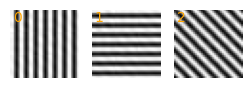

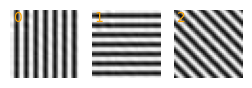

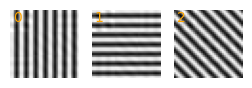

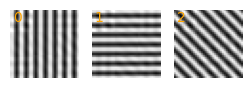

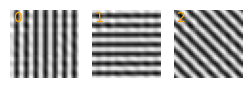

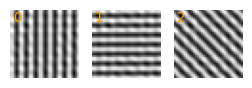

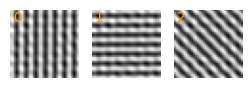

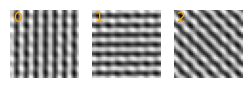

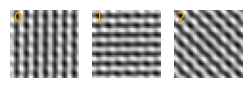

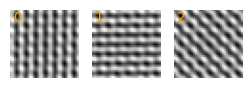

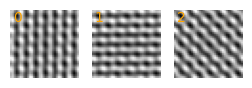

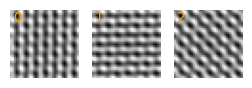

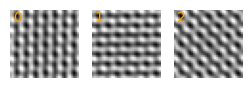

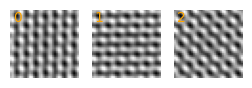

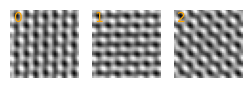

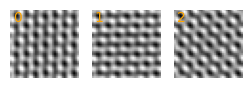

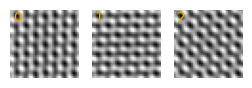

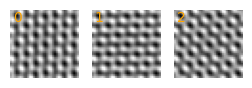

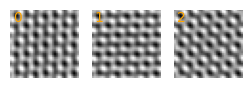

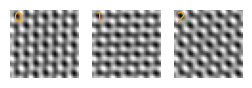

In [15]:
from models.hierarchical_grating_model import HierarchicalGratingModel

gratings = get_3_gratings()

for gratings_offset in sorted(results_part["gratings_offset"].unique()):
    g_prob = 1 / 3
    x_sigma = 0.1
    i_sigma = 1.0
    print("gratings_offset", gratings_offset)
    model = HierarchicalGratingModel(
        gratings=gratings,
        G_prob=g_prob,
        X_sigma=x_sigma,
        I_sigma=i_sigma,
        gratings_offset=gratings_offset,
    )
    model.visualize_learned_G(nrows=1, ncols=3)

Text(0, 0.5, 'activation mean')

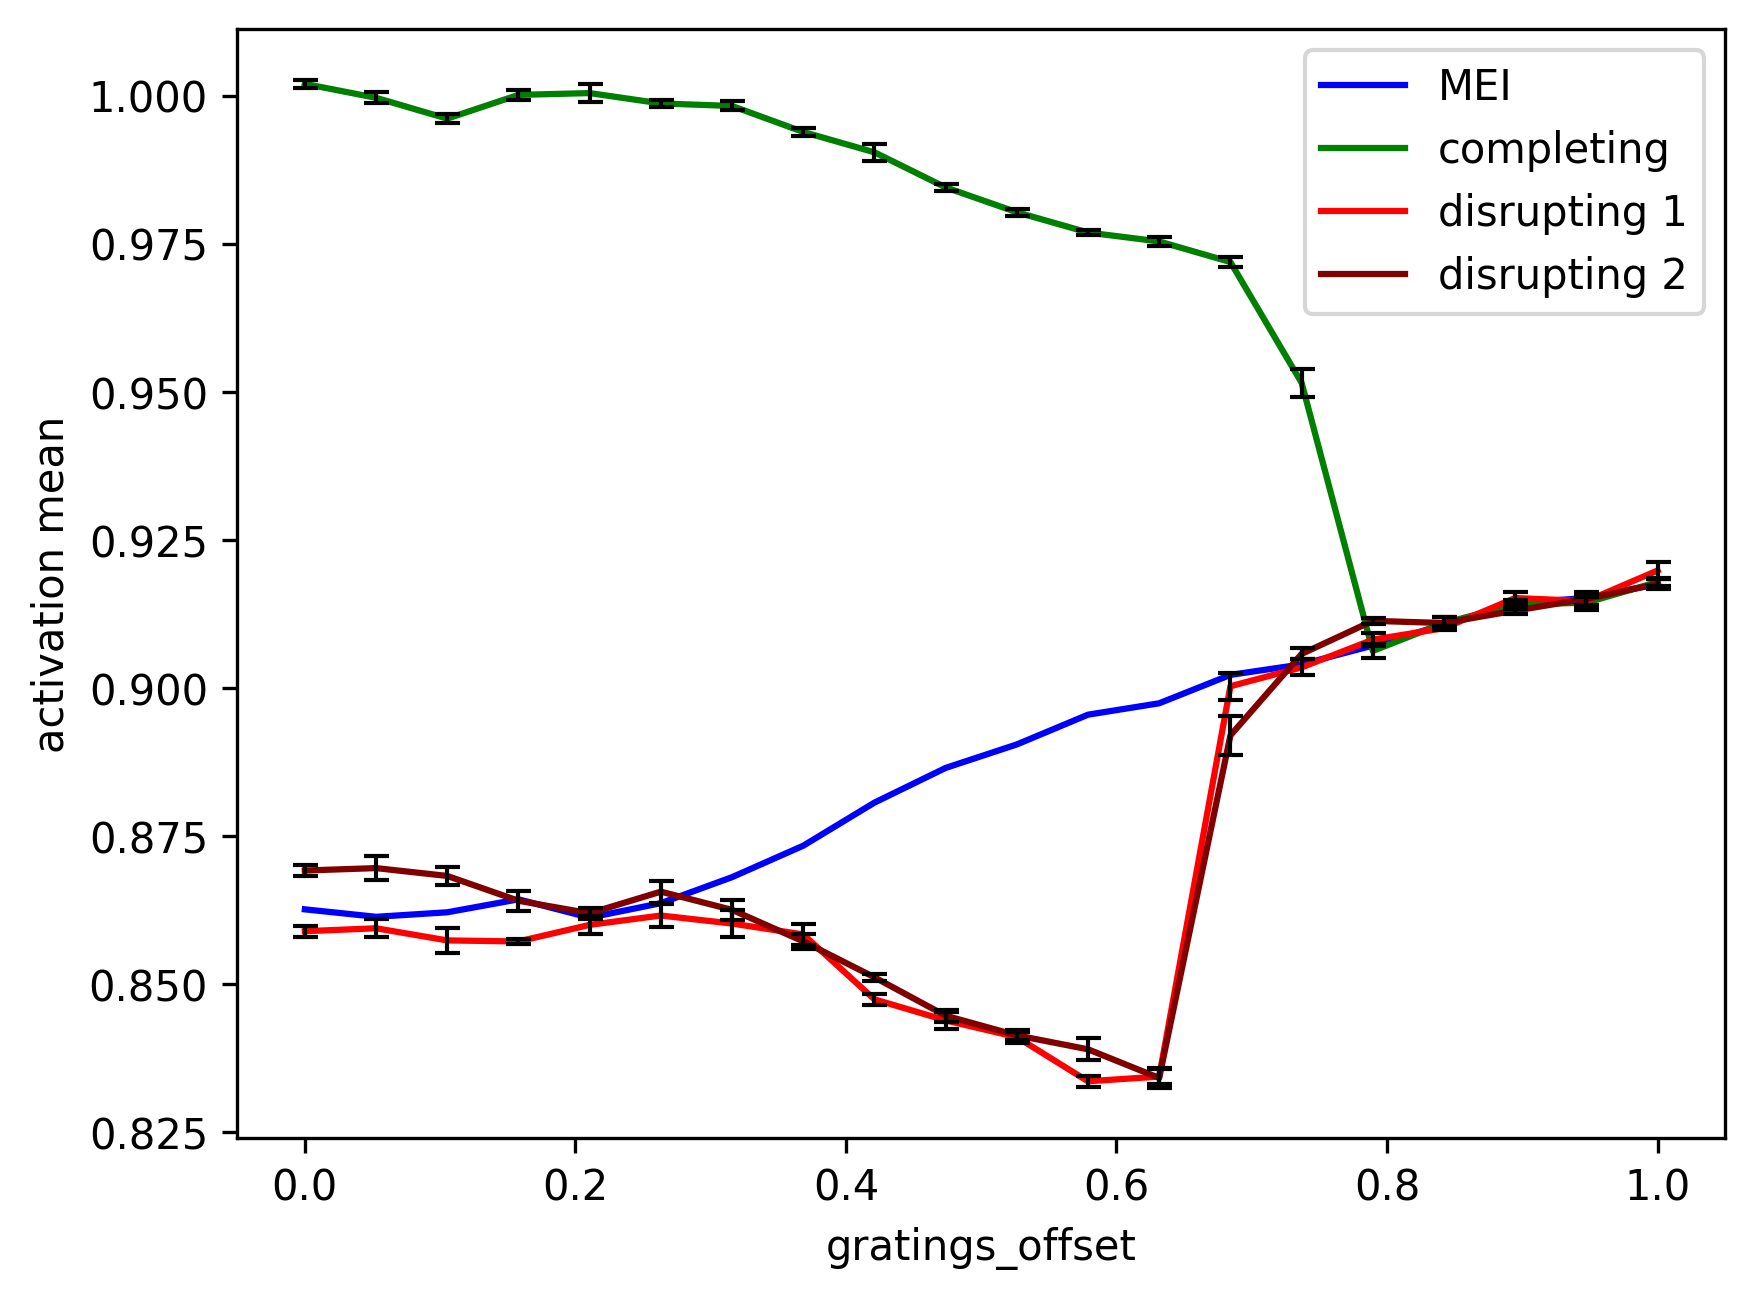

In [22]:
fig, axs = plt.subplots(dpi=300)
sns.lineplot(
    results_part,
    x="gratings_offset",
    y="mei_mean_mean_chains",
    label="MEI",
    color="blue",
)
sns.lineplot(
    results_part,
    x="gratings_offset",
    y="completing_mean_mean_chains",
    label="completing",
    color="green",
)
sns.lineplot(
    results_part,
    x="gratings_offset",
    y="disrupting_mean_mean_chains_1",
    label="disrupting 1",
    color="red",
)
sns.lineplot(
    results_part,
    x="gratings_offset",
    y="disrupting_mean_mean_chains_2",
    label="disrupting 2",
    color="maroon",
)
for gratings_offset in sorted(results_part["gratings_offset"]):
    axs.errorbar(
        x=results_part[results_part["gratings_offset"] == gratings_offset][
            "gratings_offset"
        ],
        y=results_part[results_part["gratings_offset"] == gratings_offset][
            "completing_mean_mean_chains"
        ],
        yerr=results_part[results_part["gratings_offset"] == gratings_offset][
            "completing_mean_sde_chains"
        ],
        capsize=3,
        elinewidth=1,
        capthick=1,
        color="black",
    )
    axs.errorbar(
        x=results_part[results_part["gratings_offset"] == gratings_offset][
            "gratings_offset"
        ],
        y=results_part[results_part["gratings_offset"] == gratings_offset][
            "disrupting_mean_mean_chains_1"
        ],
        yerr=results_part[results_part["gratings_offset"] == gratings_offset][
            "disrupting_mean_sde_chains_1"
        ],
        capsize=3,
        elinewidth=1,
        capthick=1,
        color="black",
    )
    axs.errorbar(
        x=results_part[results_part["gratings_offset"] == gratings_offset][
            "gratings_offset"
        ],
        y=results_part[results_part["gratings_offset"] == gratings_offset][
            "disrupting_mean_mean_chains_2"
        ],
        yerr=results_part[results_part["gratings_offset"] == gratings_offset][
            "disrupting_mean_sde_chains_2"
        ],
        capsize=3,
        elinewidth=1,
        capthick=1,
        color="black",
    )
axs.set_ylabel("activation mean")